In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(np.sin(np.pi/2))
print(np.pi/2)


1.0
1.5707963267948966


0.08333333333333333

In [6]:
time = np.linspace(0, 10*np.pi, 2000)
data = np.sin(time)

<function matplotlib.pyplot.show(close=None, block=None)>

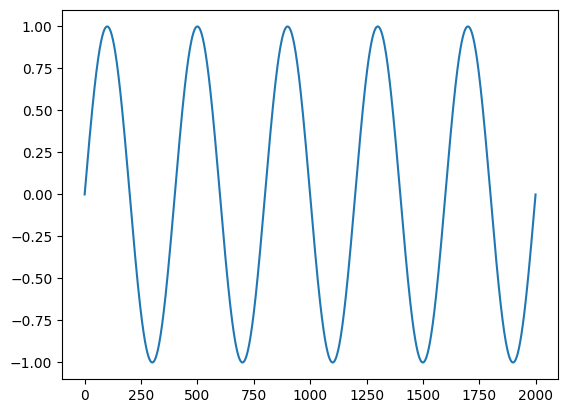

In [7]:
plt.plot(data)
plt.show

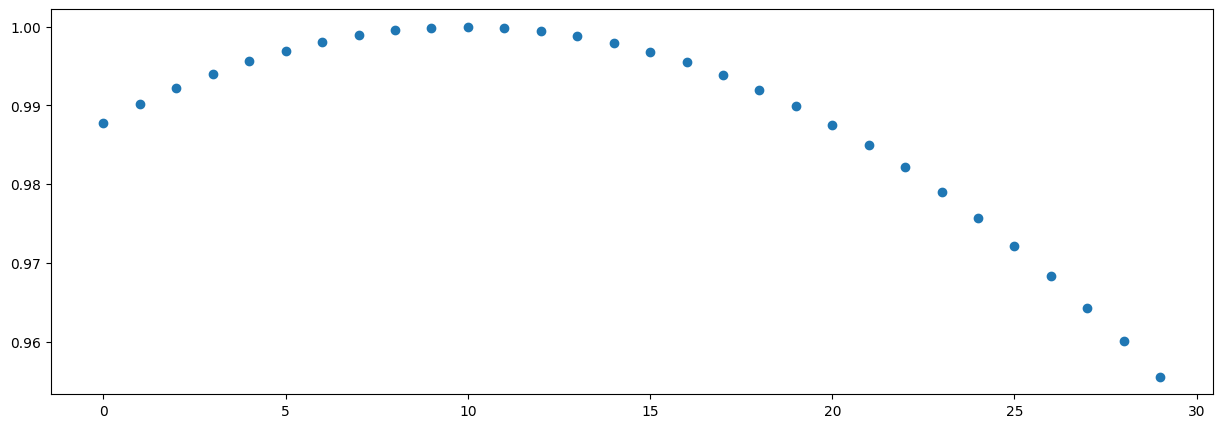

In [14]:
plt.figure(figsize=(15,5))
plt.scatter(np.arange(30), data[90:120])
plt.show()

In [21]:
seq =20
X = []
y = []

for i in range(len(data) - seq):
    X.append(data[i:i+seq])
    y.append(data[i+seq])

X = np.array(X)
y = np.array(y)


In [22]:
X.shape

(1980, 20)

In [23]:
y.shape

(1980,)

In [27]:
X = X.reshape((*X.shape, 1))

In [28]:
X.shape

(1980, 20, 1)

In [29]:
X_train, X_test = X[:1500], X[1500:]
y_train, y_test = y[:1500], y[1500:]

In [33]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [35]:
model =Sequential()
model.add(Input(shape=(20,1)))
model.add(SimpleRNN(units=32, activation='tanh'))
model.add(Dense(1, activation='linear'))

In [36]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss='mean_absolute_error', optimizer='adam')

In [40]:
model.fit(X_train, y_train, batch_size=25, epochs=10, validation_split=.2, verbose=2)

Epoch 1/10
48/48 - 1s - 13ms/step - loss: 0.0344 - val_loss: 0.0094
Epoch 2/10
48/48 - 0s - 2ms/step - loss: 0.0082 - val_loss: 0.0044
Epoch 3/10
48/48 - 0s - 2ms/step - loss: 0.0061 - val_loss: 0.0028
Epoch 4/10
48/48 - 0s - 2ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 5/10
48/48 - 0s - 2ms/step - loss: 0.0066 - val_loss: 0.0053
Epoch 6/10
48/48 - 0s - 2ms/step - loss: 0.0054 - val_loss: 0.0177
Epoch 7/10
48/48 - 0s - 2ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 8/10
48/48 - 0s - 2ms/step - loss: 0.0058 - val_loss: 0.0031
Epoch 9/10
48/48 - 0s - 1ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 10/10
48/48 - 0s - 2ms/step - loss: 0.0033 - val_loss: 0.0077


In [42]:
pred = model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


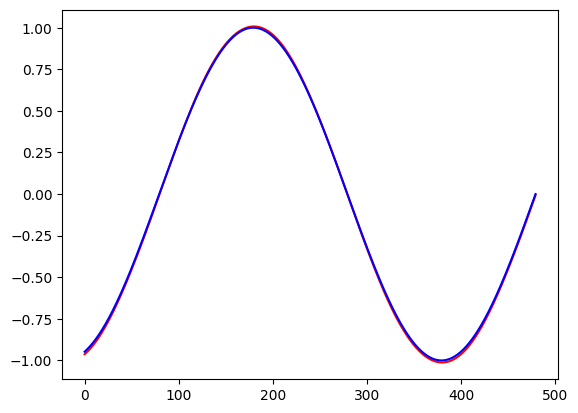

In [43]:
plt.plot(pred, color='red')
plt.plot(y_test, color='blue')
plt.show()

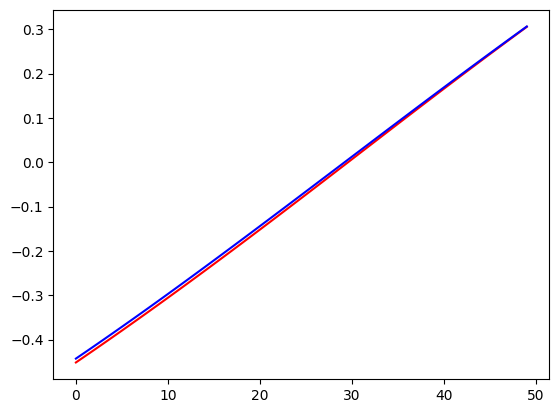

In [44]:
plt.plot(pred[50:100], color='red')
plt.plot(y_test[50:100], color='blue')
plt.show()

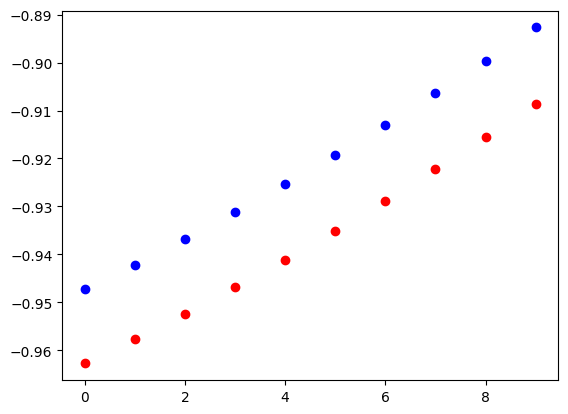

In [46]:
plt.scatter(np.arange(0,10), pred[:10], color='red')
plt.scatter(np.arange(0,10), y_test[:10], color='blue')
plt.show()